In [1]:
import pandas as pd

df = pd.read_csv("SGJobData.csv", nrows=50000)  # first 50,000 rows only

In [2]:
df.head()

,categories,employmentTypes,metadata_expiryDate,metadata_isPostedOnBehalf,metadata_jobPostId,metadata_newPostingDate,metadata_originalPostingDate,metadata_repostCount,metadata_totalNumberJobApplication,metadata_totalNumberOfView,...,occupationId,positionLevels,postedCompany_name,salary_maximum,salary_minimum,salary_type,status_id,status_jobStatus,title,average_salary
0,"[{""id"":13,""category"":""Environment / Health""},{...",Permanent,2023-05-08,False,MCF-2023-0252866,2023-04-08,2023-03-30,2,5,151,...,NaN,Executive,WORKSTONE PTE. LTD.,2800,2000,Monthly,0,Closed,Food Technologist - Clementi | Entry Level | U...,2400.0
1,"[{""id"":21,""category"":""Information Technology""}]",Permanent,2023-05-08,False,MCF-2023-0273977,2023-04-08,2023-04-08,0,0,55,...,NaN,Executive,TRUST RECRUIT PTE. LTD.,5500,4000,Monthly,0,Closed,"Software Engineer (Fab Support) (Java, CIM, Up...",4750.0
2,"[{""id"":33,""category"":""Repair and Maintenance""}]",Full Time,2023-04-22,False,MCF-2023-0273994,2023-04-08,2023-04-08,0,7,99,...,NaN,Senior Executive,PU TIEN SERVICES PTE. LTD.,4600,3800,Monthly,0,Closed,Senior Technician,4200.0
3,"[{""id"":21,""category"":""Information Technology""}]",Permanent,2023-05-08,False,MCF-2023-0273991,2023-04-08,2023-04-08,0,6,113,...,NaN,Senior Executive,TRUST RECRUIT PTE. LTD.,10000,5000,Monthly,0,Closed,"Senior .NET Developer (.NET Core, MVC, MVVC, S...",7500.0
4,"[{""id"":2,""category"":""Admin / Secretarial""}]",Full Time,2023-05-08,False,MCF-2023-0273976,2023-04-08,2023-04-08,0,3,99,...,NaN,Non-executive,EATZ CATERING SERVICES PTE. LTD.,3400,2400,Monthly,0,Closed,Sales / Admin Cordinator,2900.0


In [1]:
# %% [markdown]
# # Singapore Jobs Analytics — Data Cleaning & Feature Engineering
#
# **Assignment Section 2: Data Handling & Process**
#
# This notebook takes the raw MyCareersFuture-style CSV and produces a cleaned,
# feature-engineered dataset ready for the dashboard (salary benchmarking,
# experience premium, contract vs permanent, and tech-specialism analysis).
#
# Run cell-by-cell in VS Code (Jupyter extension) or export to `.ipynb`.

# %% [markdown]
# ## Step 0 — Load a sample and do first-pass EDA
#
# Per the assignment brief: taste a spoonful before cooking the whole pot.
# Everything here is built on a 50,000-row sample; the same logic scales to
# the full ~1M-row file later by dropping `nrows`.

# %%
import pandas as pd
import numpy as np
import json

CSV_PATH = "SGJobData.csv"  # <-- update this to your local file path

df = pd.read_csv(CSV_PATH, nrows=50_000)

print("Shape:", df.shape)
print()
df.info()
print()
print(df["average_salary"].describe())

# %% [markdown]
# ## Step 1 — Initial data-quality scan
#
# Before cleaning anything, check what's actually wrong: nulls, duplicates,
# and columns that carry no information.

# %%
print("Null counts:\n", df.isnull().sum(), "\n")
print("Fully-null columns:", df.columns[df.isnull().all()].tolist())
print("Duplicate jobPostId rows:", df["metadata_jobPostId"].duplicated().sum())
print("Fully duplicate rows:", df.duplicated().sum())
print("Constant columns (only 1 unique value):",
      [c for c in df.columns if df[c].nunique(dropna=False) == 1])

# %% [markdown]
# **Decisions:**
# - `occupationId` is 100% null in this sample → drop it.
# - `salary_type` is constant (`"Monthly"`) → not useful for analysis, but we
#   keep a note of it rather than silently dropping, in case future data has
#   other values.
# - No duplicate `jobPostId`s or fully duplicate rows found in this sample, so
#   no de-duplication needed here — but the check is kept in the pipeline so
#   it re-validates automatically if you scale up to the full file.

# %%
cols_to_drop = [c for c in ["occupationId"] if c in df.columns]
df = df.drop(columns=cols_to_drop)
df = df.drop_duplicates(subset="metadata_jobPostId", keep="first")
print("Shape after dropping empty columns / duplicate IDs:", df.shape)

# %% [markdown]
# ## Step 2 — Parse dates
#
# Three date columns arrive as strings (`YYYY-MM-DD`). Parsing them lets us
# compute posting-to-expiry duration and support a time-trend view later.

# %%
date_cols = ["metadata_expiryDate", "metadata_newPostingDate", "metadata_originalPostingDate"]
for c in date_cols:
    df[c] = pd.to_datetime(df[c], errors="coerce")

print(df[date_cols].isnull().sum())
print(df[date_cols].describe())

# %% [markdown]
# ## Step 3 — Parse `categories` (JSON array) and flag Information Technology
#
# `categories` is a JSON-array string, and a job can carry multiple categories.
# We parse it into a Python list of category names, keep the full list for
# reference, and flag rows tagged "Information Technology" — the focus of this
# assignment's business case.

# %%
def parse_categories(raw):
    try:
        items = json.loads(raw)
        return [item.get("category") for item in items if "category" in item]
    except (json.JSONDecodeError, TypeError):
        return []

df["category_list"] = df["categories"].apply(parse_categories)
df["is_it"] = df["category_list"].apply(lambda lst: "Information Technology" in lst)

print("Rows tagged Information Technology:", df["is_it"].sum())
print("Rows with unparseable categories:", (df["category_list"].apply(len) == 0).sum())

# %% [markdown]
# ## Step 4 — Standardise categorical text fields
#
# Trim whitespace and normalise casing so groupby/filter operations don't
# silently split "Permanent" from " permanent " into different groups.

# %%
text_cols = ["employmentTypes", "positionLevels", "status_jobStatus", "salary_type", "title"]
for c in text_cols:
    df[c] = df[c].astype(str).str.strip()

print("employmentTypes values:", df["employmentTypes"].unique())
print("positionLevels values:", df["positionLevels"].unique())
print("status_jobStatus values:", df["status_jobStatus"].unique())

# %% [markdown]
# ## Step 5 — Validate and clean salary fields
#
# Checks applied:
# 1. `salary_minimum` should be <= `salary_maximum` — flag violations.
# 2. `average_salary` should equal `(min + max) / 2` — recompute if it drifts.
# 3. Sanity floor: salaries below SGD 500/month are almost certainly data
#    entry errors (Singapore's minimum wage floor for even part-time work is
#    well above this) — flagged rather than silently dropped, so you can
#    decide whether to exclude them from salary-based charts.
# 4. Extreme upper outliers (e.g. one row at ~$205,000/month) are also flagged
#    rather than deleted, since a handful may be legitimate C-suite roles —
#    dropping them silently would be an unjustified judgment call.

# %%
df["salary_range_invalid"] = df["salary_minimum"] > df["salary_maximum"]
print("Rows where salary_minimum > salary_maximum:", df["salary_range_invalid"].sum())

recomputed_avg = (df["salary_minimum"] + df["salary_maximum"]) / 2
avg_mismatch = (recomputed_avg - df["average_salary"]).abs() > 1
print("Rows where average_salary doesn't match (min+max)/2:", avg_mismatch.sum())
df.loc[avg_mismatch, "average_salary"] = recomputed_avg[avg_mismatch]

low_salary_floor = 500
high_salary_ceiling = df["average_salary"].quantile(0.995)  # ~top 0.5% flagged, not dropped
df["salary_below_floor"] = df["average_salary"] < low_salary_floor
df["salary_above_p995"] = df["average_salary"] > high_salary_ceiling

print(f"Rows flagged below ${low_salary_floor}/month:", df["salary_below_floor"].sum())
print(f"Rows flagged above 99.5th pct (${high_salary_ceiling:,.0f}/month):", df["salary_above_p995"].sum())

# %% [markdown]
# ## Step 6 — Handle `numberOfVacancies` outliers
#
# Most postings ask for 1-2 headcount; a small number of "bulk hiring" postings
# (e.g. 999 vacancies) can dominate any sum-based demand metric. We flag these
# rather than drop them, and separately cap a `numberOfVacancies_capped` column
# at the 99th percentile for use in aggregate demand scoring, so one bulk
# posting doesn't distort a whole specialism's "demand" ranking.

# %%
vac_p99 = df["numberOfVacancies"].quantile(0.99)
df["is_bulk_hiring"] = df["numberOfVacancies"] > vac_p99
df["numberOfVacancies_capped"] = df["numberOfVacancies"].clip(upper=vac_p99)

print(f"99th percentile vacancies: {vac_p99:.0f}")
print("Rows flagged as bulk hiring:", df["is_bulk_hiring"].sum())

# %% [markdown]
# ## Step 7 — Feature engineering
#
# Features needed across the four analysis topics (salary benchmark by
# seniority, experience premium, contract vs permanent, specialism demand/pay).

# %%
# 7a. Seniority ranking (ordered, not just alphabetical)
seniority_order = [
    "Non-executive", "Fresh/entry level", "Junior Executive", "Executive",
    "Senior Executive", "Professional", "Manager", "Middle Management",
    "Senior Management",
]
df["seniority_rank"] = df["positionLevels"].apply(
    lambda x: seniority_order.index(x) if x in seniority_order else np.nan
)

# 7b. Salary band width
df["salary_band_width"] = df["salary_maximum"] - df["salary_minimum"]

# 7c. Experience buckets
exp_bins = [-1, 0, 2, 5, 9, 100]
exp_labels = ["0 yrs", "1-2 yrs", "3-5 yrs", "6-9 yrs", "10+ yrs"]
df["experience_bucket"] = pd.cut(df["minimumYearsExperience"], bins=exp_bins, labels=exp_labels)

# 7d. Contract vs Permanent flag (keeps full employmentTypes too)
df["is_permanent"] = df["employmentTypes"] == "Permanent"
df["is_contract"] = df["employmentTypes"] == "Contract"

# 7e. Demand/scarcity proxies (safe division — avoid the pandas .replace(0, pd.NA)
# RecursionError bug from earlier; np.where sidesteps it entirely)
vacancies_safe = np.where(df["numberOfVacancies"] == 0, np.nan, df["numberOfVacancies"])
views_safe = np.where(df["metadata_totalNumberOfView"] == 0, np.nan, df["metadata_totalNumberOfView"])
df["applicants_per_vacancy"] = df["metadata_totalNumberJobApplication"] / vacancies_safe
df["conversion_rate"] = df["metadata_totalNumberJobApplication"] / views_safe

# 7f. Technology specialism classification (IT rows only)
it_title = df.loc[df["is_it"], "title"].str.lower()
specialism = pd.Series("Other / General IT", index=df.loc[df["is_it"]].index)

specialism_rules = [
    ("Cybersecurity",
     r"\bcyber ?security\b|\bsecurity engineer\b|\bsoc analyst\b|\bpenetration test|\bpentest|\binfosec\b|\bsecurity analyst\b|\bit security\b|\bsecurity architect\b"),
    ("Data Science / AI / ML",
     r"\bdata scientist\b|\bmachine learning\b|\bml engineer\b|\bartificial intelligence\b|\bai engineer\b|\bdeep learning\b|\bnlp\b"),
    ("Data Engineering / Analytics",
     r"\bdata engineer\b|\bdata analyst\b|\bbig data\b|\bbi developer\b|\bbusiness intelligence\b|\betl\b|\bdata warehouse\b|\bdata architect\b"),
    ("Cloud / DevOps / Infrastructure",
     r"\bcloud engineer\b|\bcloud architect\b|\bdevops\b|\bsite reliability\b|\bsre\b|\bkubernetes\b|\baws\b|\bazure\b|\bgcp\b|\binfrastructure engineer\b|\bsystem administrator\b|\bsysadmin\b|\bunix\b|\blinux admin\b"),
    ("Network Engineering",
     r"\bnetwork engineer\b|\bnetwork administrator\b|\bnetwork specialist\b|\bccna\b|\bccnp\b|\btelecom(?:s)? engineer\b"),
    ("Software / Application Development",
     r"\bsoftware engineer\b|\bsoftware developer\b|\bapplication developer\b|\bfull ?stack\b|\bfront ?end\b|\bback ?end\b|\bjava developer\b|\b\.net developer\b|\bpython developer\b|\bweb developer\b|\bprogrammer\b|\bsoftware architect\b"),
    ("Mobile Development",
     r"\bmobile developer\b|\bios developer\b|\bandroid developer\b|\bmobile engineer\b|\bapp developer\b"),
    ("QA / Testing",
     r"\bqa engineer\b|\bquality assurance\b|\btest engineer\b|\bsoftware tester\b|\bautomation tester\b|\bsdet\b"),
    ("Database Administration",
     r"\bdba\b|\bdatabase administrator\b|\bdatabase engineer\b|\boracle dba\b|\bsql dba\b"),
    ("ERP / SAP",
     r"\bsap\b|\berp consultant\b|\berp\b"),
    ("IT Project / Business Analyst / PM",
     r"\bit project manager\b|\bbusiness analyst\b|\bproduct manager\b|\bscrum master\b|\bagile coach\b|\bproject manager\b.*\bit\b"),
    ("UI/UX Design",
     r"\bui/ux\b|\bui designer\b|\bux designer\b|\buser experience\b|\buser interface\b"),
    ("IT Support / Helpdesk",
     r"\bit support\b|\bhelpdesk\b|\bhelp desk\b|\bdesktop support\b|\btechnical support\b|\bit technician\b|\bservice desk\b"),
    ("Presales / IT Sales",
     r"\bpresales\b|\bpre-sales\b|\bsolutions? consultant\b|\bsales engineer\b|\bit sales\b"),
    ("Software / Application Development",
     r"\bapplication support\b|\bapplication engineer\b|\bservicenow\b|\bsolution architect\b|\bplatform engineer\b"),
    ("Cloud / DevOps / Infrastructure",
     r"\bsystems? engineer\b|\bsystems? analyst\b|\btechnical manager\b.*network|\bsystems? administrator\b"),
    ("IT Support / Helpdesk",
     r"\beuc engineer\b|\bdesktop engineer\b|\bit engineer\b|\bit manager\b|\bit executive\b"),
]

for name, pattern in specialism_rules:
    m = it_title.str.contains(pattern, regex=True, na=False)
    specialism[m & (specialism == "Other / General IT")] = name

df["specialism"] = pd.NA
df.loc[df["is_it"], "specialism"] = specialism

print(df.loc[df["is_it"], "specialism"].value_counts())

# %% [markdown]
# ## Step 8 — Final consistency check

# %%
print("Final shape:", df.shape)
print()
print("Remaining nulls (specialism is expected to be null for non-IT rows):")
print(df.isnull().sum()[df.isnull().sum() > 0])
print()
print("Flag summary:")
for flag in ["salary_range_invalid", "salary_below_floor", "salary_above_p995", "is_bulk_hiring"]:
    print(f"  {flag}: {df[flag].sum()} rows ({df[flag].mean()*100:.2f}%)")

# %% [markdown]
# ## Step 9 — Save cleaned dataset for downstream use
#
# This keeps every original column plus the flags/features above, so the
# dashboard and the four analysis scripts (salary benchmark, experience
# premium, contract vs permanent, specialism demand/pay) can all read from
# one consistent cleaned file instead of re-doing this logic each time.

# %%
OUTPUT_PATH = "cleaned_sg_jobs_sample.csv"
df.to_csv(OUTPUT_PATH, index=False)
print(f"Saved cleaned dataset to {OUTPUT_PATH} — {df.shape[0]} rows, {df.shape[1]} columns")

Shape: (50000, 22)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 22 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   categories                          50000 non-null  object 
 1   employmentTypes                     50000 non-null  object 
 2   metadata_expiryDate                 50000 non-null  object 
 3   metadata_isPostedOnBehalf           50000 non-null  bool   
 4   metadata_jobPostId                  50000 non-null  object 
 5   metadata_newPostingDate             50000 non-null  object 
 6   metadata_originalPostingDate        50000 non-null  object 
 7   metadata_repostCount                50000 non-null  int64  
 8   metadata_totalNumberJobApplication  50000 non-null  int64  
 9   metadata_totalNumberOfView          50000 non-null  int64  
 10  minimumYearsExperience              50000 non-null  int64  
 11  numberOfVacancies    

/tmp/ipykernel_176094/2389264462.py:76: FutureWarning: Treating datetime data as categorical rather than numeric in `.describe` is deprecated and will be removed in a future version of pandas. Specify `datetime_is_numeric=True` to silence this warning and adopt the future behavior now.
  print(df[date_cols].describe())
/tmp/ipykernel_176094/2389264462.py:76: FutureWarning: Treating datetime data as categorical rather than numeric in `.describe` is deprecated and will be removed in a future version of pandas. Specify `datetime_is_numeric=True` to silence this warning and adopt the future behavior now.
  print(df[date_cols].describe())
/tmp/ipykernel_176094/2389264462.py:76: FutureWarning: Treating datetime data as categorical rather than numeric in `.describe` is deprecated and will be removed in a future version of pandas. Specify `datetime_is_numeric=True` to silence this warning and adopt the future behavior now.
  print(df[date_cols].describe())


Rows tagged Information Technology: 6969
Rows with unparseable categories: 0
employmentTypes values: ['Permanent' 'Full Time' 'Part Time' 'Contract' 'Freelance' 'Temporary'
 'Flexi-work' 'Internship/Attachment']
positionLevels values: ['Executive' 'Senior Executive' 'Non-executive' 'Junior Executive'
 'Manager' 'Professional' 'Fresh/entry level' 'Middle Management'
 'Senior Management']
status_jobStatus values: ['Closed' 'Re-open']
Rows where salary_minimum > salary_maximum: 0
Rows where average_salary doesn't match (min+max)/2: 0
Rows flagged below $500/month: 271
Rows flagged above 99.5th pct ($18,000/month): 248
99th percentile vacancies: 20
Rows flagged as bulk hiring: 330
Other / General IT                    3413
Software / Application Development    1004
Cloud / DevOps / Infrastructure        621
IT Support / Helpdesk                  439
IT Project / Business Analyst / PM     363
Cybersecurity                          245
ERP / SAP                              223
Network Engin

Loaded: (50000, 36)
Rows in scope: 3537 out of 6969 IT-tagged rows
Total IT postings in scope: 3537
Total advertised vacancies: 7804
Number of specialisms tracked: 14
Overall median salary (SGD/month): 6000.0
Overall mean applicants per vacancy: 8.8
                        specialism  job_postings  total_vacancies  mean_applicants_per_vacancy  avg_conversion_rate  median_salary  p75_salary  avg_years_exp  demand_score  scarcity_score  pay_score  composite_score
                         ERP / SAP           222              448                          3.8                  0.0         7500.0      9000.0            5.0          64.3            64.3       89.3             72.6
   Cloud / DevOps / Infrastructure           620             1395                          3.5                  0.0         5725.0      7500.0            3.4          92.9            78.6       28.6             66.7
Software / Application Development           994             2411                          5.5        

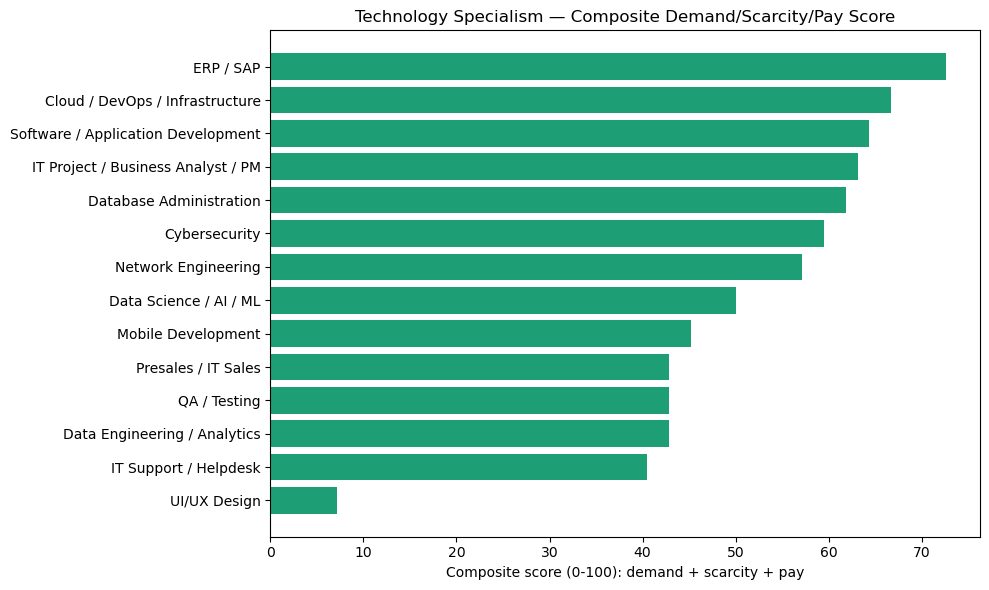

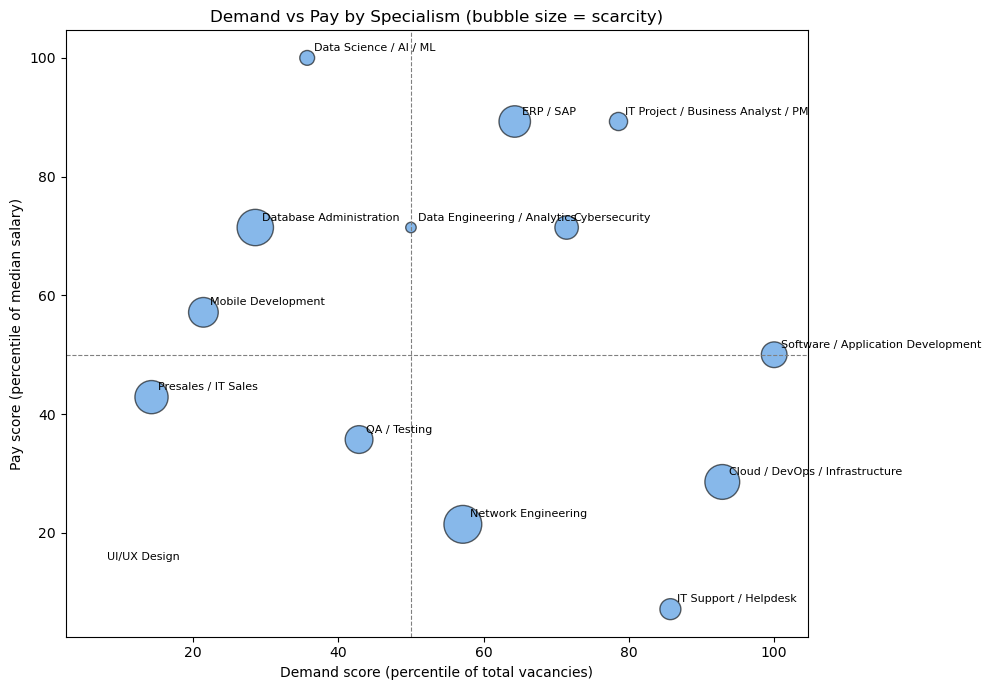

INSIGHT SUMMARY FOR TALENT ACQUISITION LEAD
- ERP / SAP: WELL-INVESTED — high demand, scarce talent, and pay already competitive (median $7,500). Protect this budget; expect these roles to stay hard to fill regardless of pay.
- Cloud / DevOps / Infrastructure: HIGH-PRIORITY GAP — strong demand and genuinely scarce talent, but pay lags the market (median $5,725). Recommend a salary-band review before the next hiring push.
- Software / Application Development: BALANCED, watch DEMAND — demand 100, scarcity 43, pay 50 (percentiles); demand is notably high (100). No urgent action, but track if demand shifts.
- IT Project / Business Analyst / PM: EASY FILL AT SCALE — high posting volume but plenty of applicant interest per role. Good candidate for standardised, lower-cost sourcing (no premium needed to compete).
- Database Administration: NICHE PREMIUM — lower volume, but acutely scarce and well-paid (median $7,000). Worth specialised/niche sourcing channels rather than generalist recruiters

In [2]:
# %% [markdown]
# # Technology Specialism — Demand, Scarcity & Pay
#
# **Business question:** Which technology specialisms combine demand, scarcity
# and pay — i.e. where should a Talent Acquisition lead prioritise sourcing
# budget and salary-band reviews?
#
# **User:** Corporate Talent Acquisition Lead (IT hiring)
#
# This builds directly on `cleaned_sg_jobs_sample.csv` (see `data_cleaning.py`)
# — no re-cleaning happens here, only analysis and insight generation, so the
# logic stays traceable to one cleaning pass per the assignment's process
# requirement.

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CLEANED_PATH = "cleaned_sg_jobs_sample.csv"  # <-- update if needed

df = pd.read_csv(CLEANED_PATH)
print("Loaded:", df.shape)

# %% [markdown]
# ## Step 1 — Scope the analysis
#
# Restrict to:
# - IT-tagged postings with a real specialism (excludes "Other / General IT" —
#   roles like admin/marketing that happened to carry a secondary IT tag).
# - Salaries inside the sane range (excludes the `salary_below_floor` and
#   `salary_above_p995` rows flagged during cleaning) so a handful of extreme
#   values don't distort the pay benchmark.
# - Uses `numberOfVacancies_capped` for demand so bulk-hiring postings
#   (flagged `is_bulk_hiring`) don't dominate the sum.

# %%
scope = (
    df["is_it"]
    & (df["specialism"].notna())
    & (df["specialism"] != "Other / General IT")
    & (~df["salary_below_floor"])
    & (~df["salary_above_p995"])
)
sd = df.loc[scope].copy()
print(f"Rows in scope: {len(sd)} out of {df['is_it'].sum()} IT-tagged rows")

# %% [markdown]
# ## Step 2 — Overview metrics
#
# The top-level numbers a TA lead would want first, before drilling into any
# one specialism.

# %%
overview = {
    "Total IT postings in scope": len(sd),
    "Total advertised vacancies": int(sd["numberOfVacancies_capped"].sum()),
    "Number of specialisms tracked": sd["specialism"].nunique(),
    "Overall median salary (SGD/month)": sd["average_salary"].median(),
    "Overall mean applicants per vacancy": round(sd["applicants_per_vacancy"].mean(), 1),
}
for k, v in overview.items():
    print(f"{k}: {v}")

# %% [markdown]
# ## Step 3 — Demand, Scarcity & Pay scoring by specialism
#
# - **Demand** = total capped vacancies, percentile-ranked (0-100).
# - **Scarcity** = inverse of mean applicants-per-vacancy, percentile-ranked
#   (fewer applicants chasing each opening = scarcer talent pool).
# - **Pay** = median `average_salary`, percentile-ranked.
# - **Composite** = simple average of the three — a single lens for
#   prioritisation, not a substitute for looking at each dimension on its own.

# %%
g = sd.groupby("specialism").agg(
    job_postings=("title", "count"),
    total_vacancies=("numberOfVacancies_capped", "sum"),
    mean_applicants_per_vacancy=("applicants_per_vacancy", "mean"),
    avg_conversion_rate=("conversion_rate", "mean"),
    median_salary=("average_salary", "median"),
    p75_salary=("average_salary", lambda x: x.quantile(0.75)),
    avg_years_exp=("minimumYearsExperience", "mean"),
).reset_index()

g["demand_score"] = g["total_vacancies"].rank(pct=True) * 100
g["scarcity_score"] = (1 - g["mean_applicants_per_vacancy"].rank(pct=True)) * 100
g["pay_score"] = g["median_salary"].rank(pct=True) * 100
g["composite_score"] = (g["demand_score"] + g["scarcity_score"] + g["pay_score"]) / 3

g = g.sort_values("composite_score", ascending=False).reset_index(drop=True)

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 20)
print(g.round(1).to_string(index=False))

g.to_csv("specialism_demand_scarcity_pay.csv", index=False)

# %% [markdown]
# ## Step 4 — Overview view: composite ranking chart

# %%
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(g["specialism"][::-1], g["composite_score"][::-1], color="#1D9E75")
ax.set_xlabel("Composite score (0-100): demand + scarcity + pay")
ax.set_title("Technology Specialism — Composite Demand/Scarcity/Pay Score")
plt.tight_layout()
plt.savefig("chart_composite_ranking.png", dpi=150)
plt.show()

# %% [markdown]
# ## Step 5 — Drill-down view: Demand vs Pay, bubble size = scarcity

# %%
fig, ax = plt.subplots(figsize=(10, 7))
sizes = g["scarcity_score"] * 8  # scale for visibility
ax.scatter(g["demand_score"], g["pay_score"], s=sizes, alpha=0.6,
           c="#378ADD", edgecolors="black")

for _, row in g.iterrows():
    ax.annotate(row["specialism"], (row["demand_score"], row["pay_score"]),
                fontsize=8, xytext=(5, 5), textcoords="offset points")

ax.axvline(50, color="grey", linestyle="--", linewidth=0.8)
ax.axhline(50, color="grey", linestyle="--", linewidth=0.8)
ax.set_xlabel("Demand score (percentile of total vacancies)")
ax.set_ylabel("Pay score (percentile of median salary)")
ax.set_title("Demand vs Pay by Specialism (bubble size = scarcity)")
plt.tight_layout()
plt.savefig("chart_demand_vs_pay_bubble.png", dpi=150)
plt.show()

# %% [markdown]
# ## Step 6 — Generate the insight narrative
#
# Per the assignment's "Insight & story" criterion, findings should read as
# **answers**, not just charts. This section programmatically turns the scored
# table into plain-English statements a TA lead can act on directly.

# %%
def describe_specialism(row):
    """Generate a one-line, decision-oriented insight for a specialism."""
    high = lambda s: s >= 60
    low = lambda s: s <= 40

    demand, scarcity, pay = row["demand_score"], row["scarcity_score"], row["pay_score"]
    name = row["specialism"]

    if high(demand) and high(scarcity) and low(pay):
        return (f"{name}: HIGH-PRIORITY GAP — strong demand and genuinely scarce talent, "
                f"but pay lags the market (median ${row['median_salary']:,.0f}). "
                f"Recommend a salary-band review before the next hiring push.")
    if high(demand) and high(scarcity) and high(pay):
        return (f"{name}: WELL-INVESTED — high demand, scarce talent, and pay already "
                f"competitive (median ${row['median_salary']:,.0f}). Protect this budget; "
                f"expect these roles to stay hard to fill regardless of pay.")
    if high(demand) and low(scarcity):
        return (f"{name}: EASY FILL AT SCALE — high posting volume but plenty of applicant "
                f"interest per role. Good candidate for standardised, lower-cost sourcing "
                f"(no premium needed to compete).")
    if low(demand) and high(scarcity) and high(pay):
        return (f"{name}: NICHE PREMIUM — lower volume, but acutely scarce and well-paid "
                f"(median ${row['median_salary']:,.0f}). Worth specialised/niche sourcing "
                f"channels rather than generalist recruiters.")
    if low(demand) and low(scarcity):
        return (f"{name}: LOW PRIORITY — limited demand and limited scarcity signal in "
                f"this data; not a near-term sourcing focus.")

    # Fall-through: still give a directional read instead of a flat "mixed" label,
    # by naming whichever dimension is furthest from the middle.
    dims = {"demand": demand, "scarcity": scarcity, "pay": pay}
    dominant = max(dims, key=lambda k: abs(dims[k] - 50))
    dom_val = dims[dominant]
    direction = "notably high" if dom_val > 50 else "notably low"
    return (f"{name}: BALANCED, watch {dominant.upper()} — demand {demand:.0f}, "
            f"scarcity {scarcity:.0f}, pay {pay:.0f} (percentiles); {dominant} is "
            f"{direction} ({dom_val:.0f}). No urgent action, but track if {dominant} shifts.")


print("=" * 100)
print("INSIGHT SUMMARY FOR TALENT ACQUISITION LEAD")
print("=" * 100)
for _, row in g.iterrows():
    print("-", describe_specialism(row))

# %% [markdown]
# ## Step 7 — Headline answer (the one-slide takeaway)

# %%
top3 = g.head(3)
gap_flag = g[(g["demand_score"] >= 60) & (g["scarcity_score"] >= 60) & (g["pay_score"] <= 40)]

print("HEADLINE ANSWER")
print("-" * 60)
print(f"Top specialisms combining demand, scarcity and pay: "
      f"{', '.join(top3['specialism'].tolist())}.")
if len(gap_flag) > 0:
    print(f"\nSpecialisms with a pay gap relative to their demand/scarcity "
          f"(review salary bands): {', '.join(gap_flag['specialism'].tolist())}.")
else:
    print("\nNo specialism currently shows a large pay gap relative to its "
          "demand/scarcity signal.")